In [7]:
#Model Formulation T1 and T2
import pandas as pd

# Full file path (use raw string to avoid backslash issues)
file_path = r"C:\Users\rakib\Documents\bangladesh_2000_2024.xlsx"

# Load the Excel file
df = pd.read_excel(file_path)

# Check that the required column exists
if 'temp_mean' not in df.columns:
    raise ValueError("Column 'temp_mean' not found in the dataset")

# Compute statistics
T_avg = df['temp_mean'].mean()
T_max = df['temp_mean'].max()
T_min = df['temp_mean'].min()

# Print results
print(f"Average mean temperature (2000–2024): {T_avg:.2f} °C")
print(f"Maximum mean temperature: {T_max:.2f} °C")
print(f"Minimum mean temperature: {T_min:.2f} °C")


Average mean temperature (2000–2024): 25.00 °C
Maximum mean temperature: 30.95 °C
Minimum mean temperature: 13.21 °C


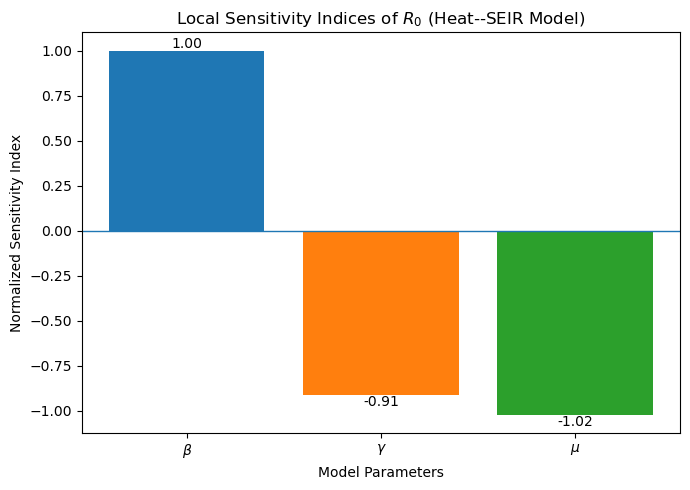

In [8]:
# Local sensitivity indices of the basic reproduction number R0 
import matplotlib.pyplot as plt

parameters = [r'$\beta$', r'$\gamma$', r'$\mu$']
sensitivity_indices = [1.0, -0.91, -1.02]

# ✅ Define different colors
colors = ['tab:blue', 'tab:orange', 'tab:green']

plt.figure(figsize=(7,5))
bars = plt.bar(parameters, sensitivity_indices, color=colors)

plt.axhline(0, linewidth=1)

plt.ylabel('Normalized Sensitivity Index')
plt.xlabel('Model Parameters')
plt.title(r'Local Sensitivity Indices of $R_0$ (Heat--SEIR Model)')

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom' if height >= 0 else 'top'
    )

plt.tight_layout()
plt.show()

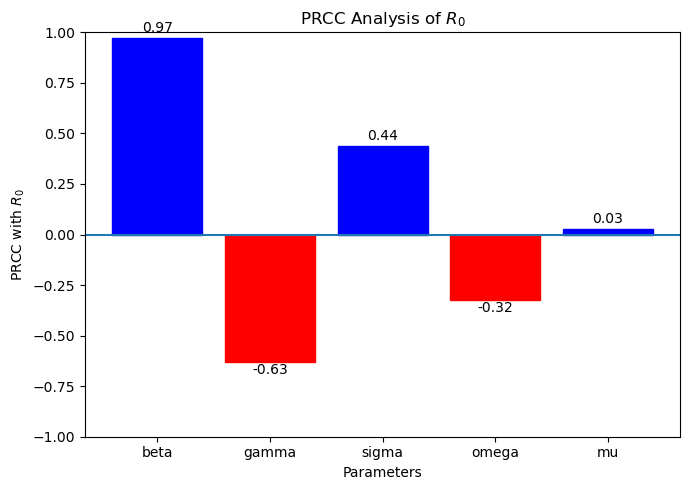


PRCC Results:
beta: 0.9723
sigma: 0.4363
gamma: -0.6298
mu: 0.0256
omega: -0.3236


In [4]:
# Partial Rank Correlation Coefficient (PRCC) analysis of the basic reproduction number (R0)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# -----------------------------
# Reproducibility
# -----------------------------
np.random.seed(42)

# Sample size
N = 1000

# -----------------------------
# Parameter ranges (varying only key parameters)
# -----------------------------
param_ranges = {
    'beta': [0.3, 0.8],
    'sigma': [0.01, 0.05],
    'gamma': [0.005, 0.03],
    'mu': [1e-5, 1e-3],
    'omega': [0.005, 0.02]
}

# -----------------------------
# Fixed parameters
# -----------------------------
theta1 = 0.05
theta3 = 0.05
Lambda = 1000
T1 = 0.6
T2 = 0.4

# -----------------------------
# Latin Hypercube Sampling
# -----------------------------
def lhs_sampling(n_samples, n_params):
    result = np.zeros((n_samples, n_params))
    for i in range(n_params):
        perm = np.random.permutation(n_samples)
        result[:, i] = (perm + np.random.rand(n_samples)) / n_samples
    return result

num_params = len(param_ranges)
lhs_samples = lhs_sampling(N, num_params)

# Scale samples to actual ranges
params = {}
for i, key in enumerate(param_ranges):
    low, high = param_ranges[key]
    params[key] = low + (high - low) * lhs_samples[:, i]

df = pd.DataFrame(params)

# -----------------------------
# Compute R0 (YOUR MODEL)
# -----------------------------
R0 = (
    df['beta'] * df['sigma'] * Lambda
) / (
    (df['mu'] + theta1 * T1) *
    (df['sigma'] + df['mu']) *
    (df['gamma'] + df['mu'] + df['omega'] + theta3 * (T1 + T2))
)

df['R0'] = R0

# -----------------------------
# Rank transform
# -----------------------------
ranked = df.rank()

# -----------------------------
# PRCC computation
# -----------------------------
def compute_prcc(data, target):
    prcc_vals = {}
    for col in data.columns:
        if col == target:
            continue

        others = data.drop(columns=[col, target])

        # Residuals for parameter
        beta_x = np.linalg.lstsq(others, data[col], rcond=None)[0]
        res_x = data[col] - others @ beta_x

        # Residuals for R0
        beta_y = np.linalg.lstsq(others, data[target], rcond=None)[0]
        res_y = data[target] - others @ beta_y

        # Spearman correlation
        prcc, _ = spearmanr(res_x, res_y)
        prcc_vals[col] = prcc

    return prcc_vals

prcc_results = compute_prcc(ranked, 'R0')

# -----------------------------
# Plot (FINAL VERSION)
# -----------------------------
prcc_df = pd.DataFrame({
    'Parameter': list(prcc_results.keys()),
    'PRCC': list(prcc_results.values())
})

# Sort by importance
prcc_df = prcc_df.reindex(prcc_df.PRCC.abs().sort_values(ascending=False).index)

# Color coding
colors = ['blue' if v > 0 else 'red' for v in prcc_df['PRCC']]

plt.figure(figsize=(7,5))
bars = plt.bar(prcc_df['Parameter'], prcc_df['PRCC'])

# Apply colors
for bar, color in zip(bars, colors):
    bar.set_color(color)

# Zero reference line
plt.axhline(0)

# 🔥 Fixed PRCC range
plt.ylim(-1, 1)

# Labels and title
plt.xlabel('Parameters')
plt.ylabel('PRCC with $R_0$')
plt.title('PRCC Analysis of $R_0$')

plt.xticks(rotation=0, ha='center')

# Value labels
for i, v in enumerate(prcc_df['PRCC']):
    plt.text(i, v + (0.03 if v > 0 else -0.06), f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()

# -----------------------------
# Print Results
# -----------------------------
print("\nPRCC Results:")
for k, v in prcc_results.items():
    print(f"{k}: {v:.4f}")

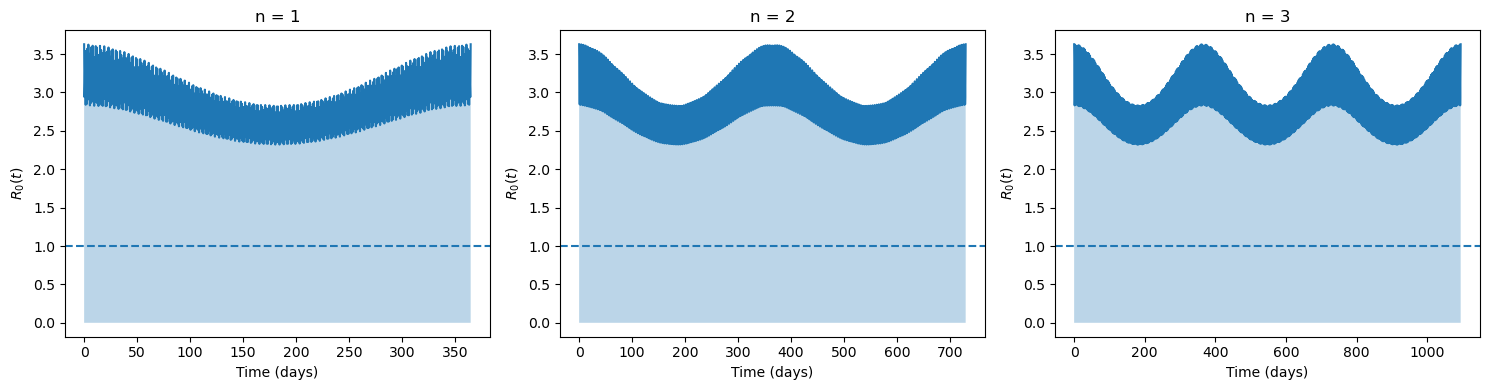

In [3]:
#Time series of the basic reproduction number R0 for the Heat-SEIR model
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameters (UPDATED)
# -----------------------------
beta = 1.2
sigma = 0.2
gamma = 0.05
mu = 0.01
omega = 0.005
theta3 = 0.01

# Temperature parameters
A = 8.87
T_mean = 25

# -----------------------------
# Temperature functions
# -----------------------------
def T1(t):
    return A * (np.sin(np.pi * t / 365))**2 + T_mean

def T2(t, n):
    return A * (np.sin(np.pi * t / n))**2

# -----------------------------
# R0(t)
# -----------------------------
def R0_t(t, n):
    return (beta * sigma) / (
        (sigma + mu) *
        (gamma + mu + omega + theta3 * (T1(t) + T2(t, n)))
    )

# -----------------------------
# Time ranges
# -----------------------------
time_ranges = {
    1: np.linspace(0, 365, 1000),
    2: np.linspace(0, 730, 2000),
    3: np.linspace(0, 1095, 3000)
}

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, n in enumerate([1, 2, 3]):
    t = time_ranges[n]
    R0_vals = R0_t(t, n)
    
    axes[i].plot(t, R0_vals)
    axes[i].fill_between(t, R0_vals, alpha=0.3)
    
    # Threshold line R0 = 1
    axes[i].axhline(1, linestyle='--')
    
    axes[i].set_title(f'n = {n}')
    axes[i].set_xlabel('Time (days)')
    axes[i].set_ylabel('$R_0(t)$')

# No grid (as requested)
plt.tight_layout()
plt.show()

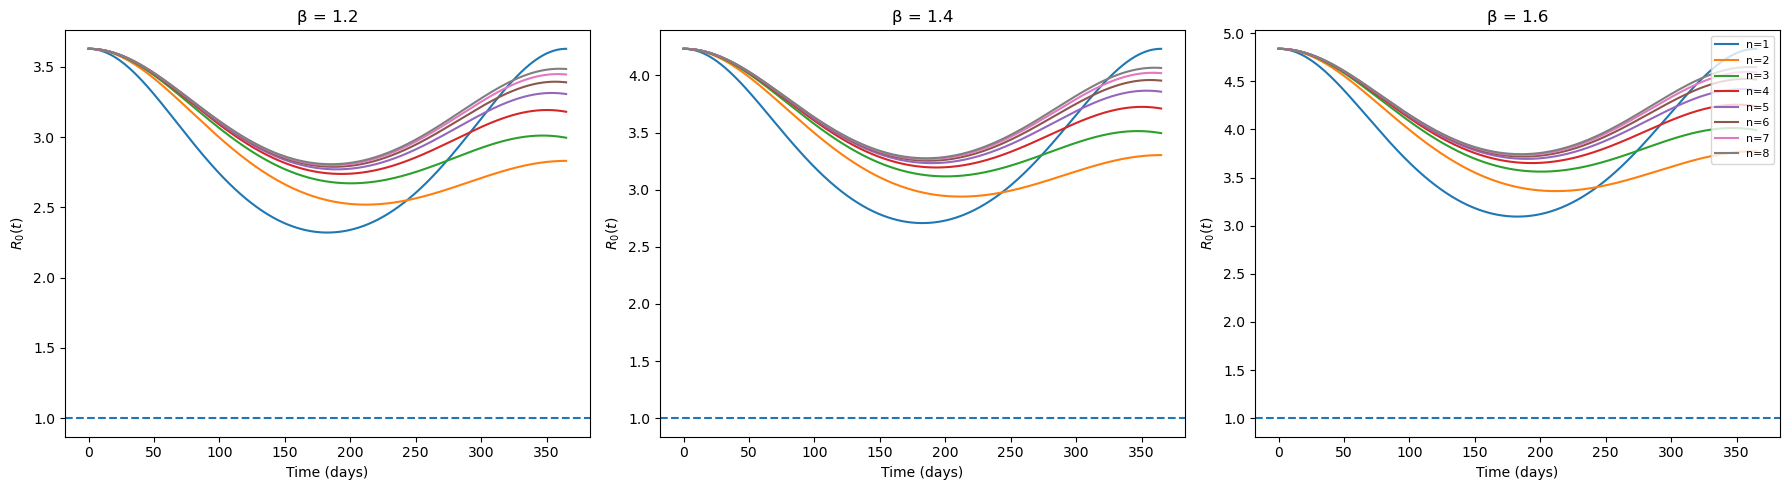

In [2]:
# Seasonal variation of R0 under heatwave dynamics across different transmission rates
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Fixed Parameters
# -----------------------------
sigma = 0.2
gamma = 0.05
mu = 0.01
omega = 0.005
theta3 = 0.01

# Beta values (around your baseline)
beta_values = [1.2, 1.4, 1.6]

# Temperature parameters
A = 8.87
T_mean = 25

# -----------------------------
# Temperature Functions
# -----------------------------
def T1(t):
    return A * (np.sin(np.pi * t / 365))**2 + T_mean

def T2(t, n):
    return A * (np.sin(np.pi * t / (365 * n)))**2

# -----------------------------
# R0(t)
# -----------------------------
def R0_t(t, beta, n):
    return (beta * sigma) / (
        (sigma + mu) *
        (gamma + mu + omega + theta3 * (T1(t) + T2(t, n)))
    )

# -----------------------------
# Time (fixed to 1 year)
# -----------------------------
t = np.linspace(0, 365, 1500)

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, beta in enumerate(beta_values):
    ax = axes[i]
    
    for n in range(1, 9):  # n = 1 to 8
        R0_vals = R0_t(t, beta, n)
        ax.plot(t, R0_vals, label=f'n={n}')
    
    # Threshold line
    ax.axhline(1, linestyle='--')
    
    ax.set_title(f'β = {beta}')
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('$R_0(t)$')
    
# Only one legend (clean look)
axes[-1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

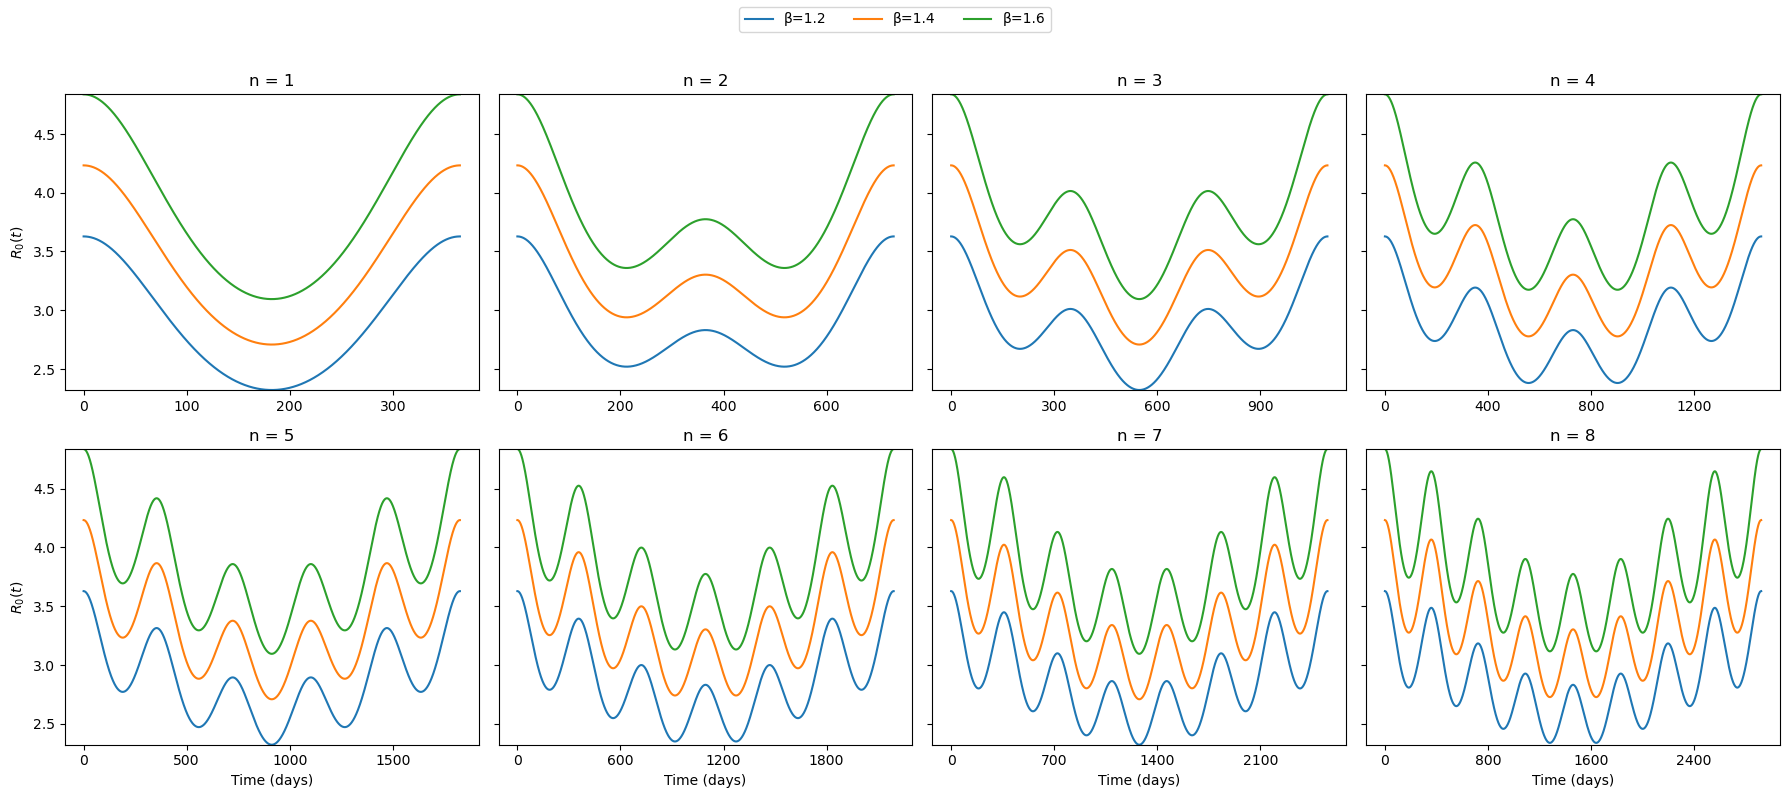

In [1]:
# Seasonal variation of R0 under heatwave dynamics across different transmission rates (β = 1.2,1.4,1.6) and seasonal cycles (n = 1to8)
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Fixed Parameters
# -----------------------------
sigma = 0.2
gamma = 0.05
mu = 0.01
omega = 0.005
theta3 = 0.01

beta_values = [1.2, 1.4, 1.6]

# Temperature parameters
A = 8.87
T_mean = 25

# -----------------------------
# Temperature Functions
# -----------------------------
def T1(t):
    return A * (np.sin(np.pi * t / 365))**2 + T_mean

def T2(t, n):
    return A * (np.sin(np.pi * t / (365 * n)))**2

# -----------------------------
# R0(t)
# -----------------------------
def R0_t(t, beta, n):
    return (beta * sigma) / (
        (sigma + mu) *
        (gamma + mu + omega + theta3 * (T1(t) + T2(t, n)))
    )

# -----------------------------
# Create 2x4 subplot
# -----------------------------
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)

axes = axes.flatten()

# -----------------------------
# Compute global y-limits
# -----------------------------
all_R0 = []

for n in range(1, 9):
    t = np.linspace(0, 365 * n, 1000)
    for beta in beta_values:
        all_R0.append(R0_t(t, beta, n))

y_min = min([np.min(arr) for arr in all_R0])
y_max = max([np.max(arr) for arr in all_R0])

# -----------------------------
# Plot each panel
# -----------------------------
for i, n in enumerate(range(1, 9)):
    
    ax = axes[i]
    t_max = 365 * n
    t = np.linspace(0, t_max, 1500)
    
    for beta in beta_values:
        R0_vals = R0_t(t, beta, n)
        ax.plot(t, R0_vals, label=f'β={beta}')
    
    # Threshold line
    ax.axhline(1, linestyle='--')
    
    # Custom x-ticks
    step = 100 * n
    xticks = np.arange(0, t_max + 1, step)
    ax.set_xticks(xticks)
    
    ax.set_title(f'n = {n}')
    
    # Only label outer axes (clean look)
    if i % 4 == 0:
        ax.set_ylabel('$R_0(t)$')
    if i >= 4:
        ax.set_xlabel('Time (days)')
    
    ax.set_ylim(y_min, y_max)

# -----------------------------
# Global legend
# -----------------------------
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

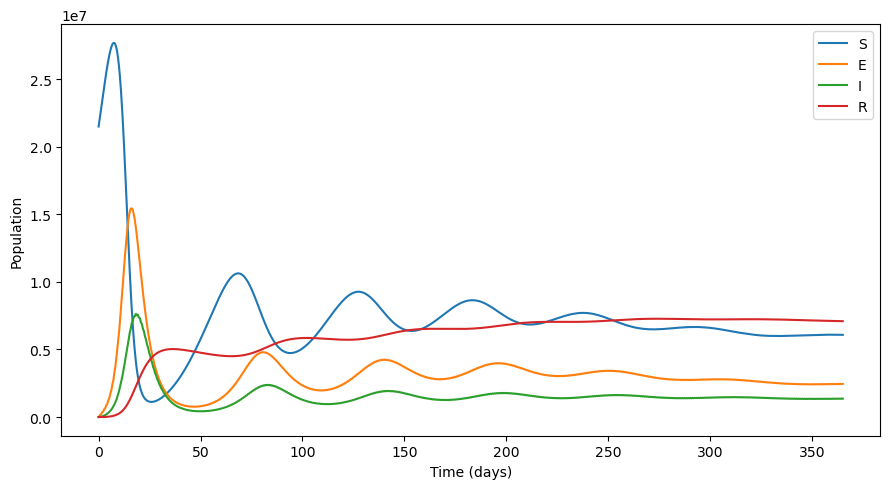

In [9]:
#Representation of heat dynamics based on Heat-SEIR model
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# -----------------------------
# Parameters
# -----------------------------
N = 21_500_000

beta = 1.2
sigma = 0.2
gamma = 0.05
mu = 0.01
omega = 0.005

theta1 = 0.002   # you must tune these
theta2 = 0.002
theta3 = 0.01

Lambda = mu * N

# Temperature parameters
A = 8.87
T_mean = 25
n = 1   # you can change this (1–8)

# -----------------------------
# Temperature functions
# -----------------------------
def T1(t):
    return A * (np.sin(np.pi * t / 365))**2 + T_mean

def T2(t):
    return A * (np.sin(np.pi * t / n))**2

# -----------------------------
# R0(t) (for analysis if needed)
# -----------------------------
def R0_t(t):
    return (beta * sigma) / (
        (sigma + mu) *
        (gamma + mu + omega + theta3 * (T1(t) + T2(t)))
    )

# -----------------------------
# SEIR System (Your Model)
# -----------------------------
def model(y, t):
    S, E, I, R = y

    dSdt = Lambda - beta * S * I / N + theta1 * T1(t) * S - mu * S
    dEdt = beta * S * I / N + theta2 * T2(t) * S - (sigma + mu) * E
    dIdt = sigma * E - (gamma + mu + omega + theta3 * (T1(t) + T2(t))) * I
    dRdt = gamma * I - mu * R

    return [dSdt, dEdt, dIdt, dRdt]

# -----------------------------
# Initial Conditions
# -----------------------------
I0 = 1000
E0 = 500
R0_init = 0
S0 = N - I0 - E0 - R0_init

y0 = [S0, E0, I0, R0_init]

# -----------------------------
# Time Grid (1 year)
# -----------------------------
t = np.linspace(0, 365, 1500)

# -----------------------------
# Solve ODE
# -----------------------------
sol = odeint(model, y0, t)
S, E, I, R = sol.T

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(9,5))

plt.plot(t, S, label='S')
plt.plot(t, E, label='E')
plt.plot(t, I, label='I')
plt.plot(t, R, label='R')

plt.xlabel('Time (days)')
plt.ylabel('Population')


plt.legend()
plt.tight_layout()
plt.show()

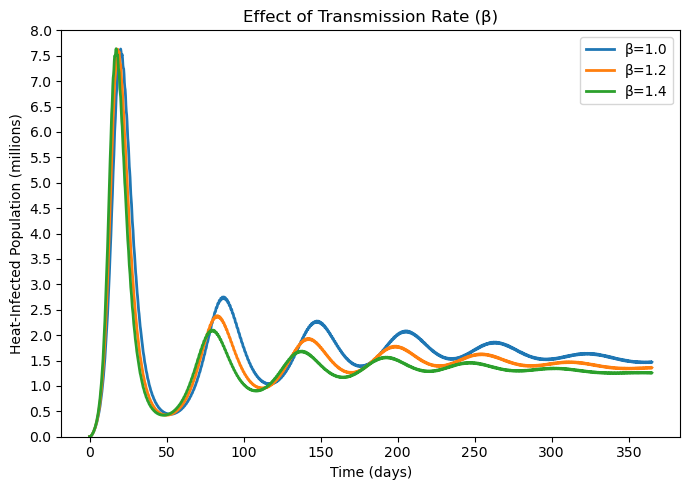

In [10]:
# Impact of transmission rate (β) on heat-SEIR outbreak dynamics
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# -----------------------------
# Parameters (same as your model)
# -----------------------------
N = 21_500_000

sigma = 0.2
gamma = 0.05
mu = 0.01
omega = 0.005

theta1 = 0.002
theta2 = 0.002
theta3 = 0.01

Lambda = mu * N

# Beta values (only 3)
beta_values = [1.0, 1.2, 1.4]

# Temperature parameters
A = 8.87
T_mean = 25

# -----------------------------
# Temperature functions
# -----------------------------
def T1(t):
    return A * (np.sin(np.pi * t / 365))**2 + T_mean

def T2(t):
    return A * (np.sin(np.pi * t / 1))**2

# -----------------------------
# SEIR model
# -----------------------------
def model(y, t, beta):
    S, E, I, R = y

    dSdt = Lambda - beta * S * I / N + theta1 * T1(t) * S - mu * S
    dEdt = beta * S * I / N + theta2 * T2(t) * S - (sigma + mu) * E
    dIdt = sigma * E - (gamma + mu + omega + theta3 * (T1(t) + T2(t))) * I
    dRdt = gamma * I - mu * R

    return [dSdt, dEdt, dIdt, dRdt]

# -----------------------------
# Initial Conditions
# -----------------------------
I0 = 1000
E0 = 500
R0_init = 0
S0 = N - I0 - E0 - R0_init

y0 = [S0, E0, I0, R0_init]

# -----------------------------
# Time grid
# -----------------------------
t = np.linspace(0, 365, 1500)

# -----------------------------
# Find max for scaling
# -----------------------------
all_I = []

for beta in beta_values:
    sol = odeint(model, y0, t, args=(beta,))
    all_I.append(sol[:,2])

y_max = max([max(I) for I in all_I]) / 1e6  # convert to millions

# -----------------------------
# Plot (Single Graph)
# -----------------------------
plt.figure(figsize=(7,5))

for beta in beta_values:
    sol = odeint(model, y0, t, args=(beta,))
    I = sol[:,2] / 1e6   # convert to millions
    plt.plot(t, I, linewidth=2, label=f'β={beta}')

plt.xlabel('Time (days)')
plt.ylabel('Heat-Infected Population (millions)')
plt.title('Effect of Transmission Rate (β)')
plt.ylim(0, y_max)
plt.yticks(np.arange(0, y_max + 0.5, 0.5))
plt.legend()

plt.tight_layout()
plt.show()

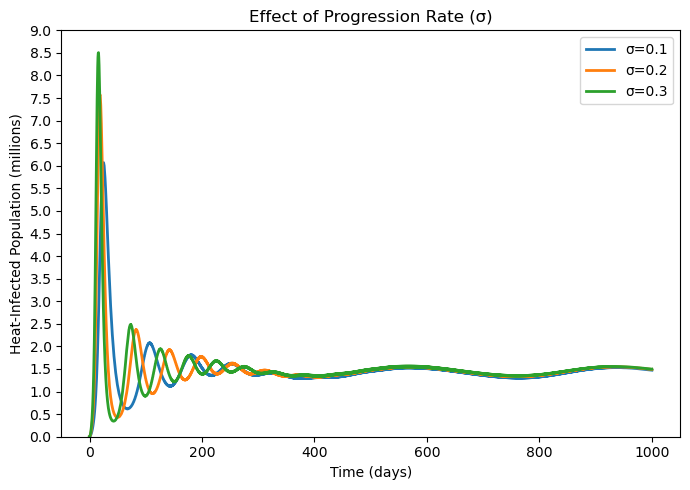

In [12]:
#Effect of progression rate (σ) on the temporal dynamics of active infections in the heat SEIR model
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# -----------------------------
# Parameters (fixed)
# -----------------------------
N = 21_500_000

beta = 1.2
gamma = 0.05
mu = 0.01
omega = 0.005

theta1 = 0.002
theta2 = 0.002
theta3 = 0.01

Lambda = mu * N

# Sigma values (only 3)
sigma_values = [0.1, 0.2, 0.3]

# Temperature parameters
A = 8.87
T_mean = 25

# -----------------------------
# Temperature functions
# -----------------------------
def T1(t):
    return A * (np.sin(np.pi * t / 365))**2 + T_mean

def T2(t):
    return A * (np.sin(np.pi * t / 1))**2

# -----------------------------
# SEIR model
# -----------------------------
def model(y, t, sigma):
    S, E, I, R = y

    dSdt = Lambda - beta * S * I / N + theta1 * T1(t) * S - mu * S
    dEdt = beta * S * I / N + theta2 * T2(t) * S - (sigma + mu) * E
    dIdt = sigma * E - (gamma + mu + omega + theta3 * (T1(t) + T2(t))) * I
    dRdt = gamma * I - mu * R

    return [dSdt, dEdt, dIdt, dRdt]

# -----------------------------
# Initial conditions
# -----------------------------
I0 = 1000
E0 = 500
R0_init = 0
S0 = N - I0 - E0 - R0_init

y0 = [S0, E0, I0, R0_init]

# -----------------------------
# Time grid
# -----------------------------
t = np.linspace(0, 1000, 2000)

# -----------------------------
# Find max for scaling
# -----------------------------
all_I = []

for sigma in sigma_values:
    sol = odeint(model, y0, t, args=(sigma,))
    all_I.append(sol[:,2])

y_max = max([max(I) for I in all_I]) / 1e6  # convert to millions

# -----------------------------
# Plot (Single Graph)
# -----------------------------
plt.figure(figsize=(7,5))

for sigma in sigma_values:
    sol = odeint(model, y0, t, args=(sigma,))
    I = sol[:,2] / 1e6   # convert to millions
    plt.plot(t, I, linewidth=2, label=f'σ={sigma}')

plt.xlabel('Time (days)')
plt.ylabel('Heat-Infected Population (millions)')
plt.title('Effect of Progression Rate (σ)')
plt.ylim(0, y_max)
plt.yticks(np.arange(0, y_max + 0.5, 0.5))
plt.legend()

plt.tight_layout()
plt.show()

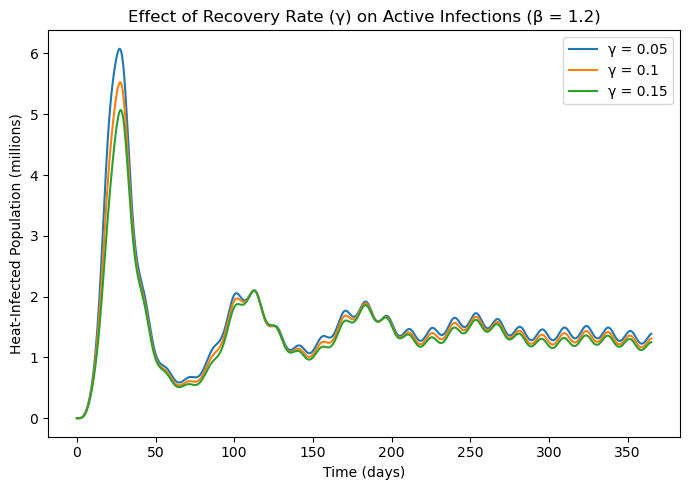

In [13]:
#Effect of recovery rate (γ) on the temporal dynamics of active infections in the heat-SEIR model for transmission rate (β = 1.2)
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# -----------------------------
# Parameters (fixed)
# -----------------------------
N = 21_500_000

beta = 1.2
gamma_values = [0.05, 0.10, 0.15]

mu = 0.01
omega = 0.005
sigma = 0.1

theta1 = 0.002
theta2 = 0.002
theta3 = 0.01

Lambda = mu * N

# -----------------------------
# Temperature functions
# -----------------------------
A = 8.87
T_mean = 25

def T1(t):
    return A * (np.sin(np.pi * t / 365))**2 + T_mean

def T2(t):
    return A * (np.sin(np.pi * t / 14))**2

# -----------------------------
# SEIR model
# -----------------------------
def model(y, t, gamma):
    S, E, I, R = y

    dSdt = Lambda - beta * S * I / N + theta1 * T1(t) * S - mu * S
    dEdt = beta * S * I / N + theta2 * T2(t) * S - (sigma + mu) * E
    dIdt = sigma * E - (gamma + mu + omega + theta3 * (T1(t) + T2(t))) * I
    dRdt = gamma * I - mu * R

    return [dSdt, dEdt, dIdt, dRdt]

# -----------------------------
# Initial conditions
# -----------------------------
I0 = 1000
E0 = 500
R0_init = 0
S0 = N - I0 - E0 - R0_init

y0 = [S0, E0, I0, R0_init]

# -----------------------------
# Time grid
# -----------------------------
t = np.linspace(0, 365, 1500)

# -----------------------------
# Plot (single figure)
# -----------------------------
plt.figure(figsize=(7,5))

for gamma in gamma_values:
    sol = odeint(model, y0, t, args=(gamma,))
    I = sol[:,2] / 1e6  # convert to millions
    plt.plot(t, I, label=f'γ = {gamma}')

plt.title('Effect of Recovery Rate (γ) on Active Infections (β = 1.2)')
plt.xlabel('Time (days)')
plt.ylabel('Heat-Infected Population (millions)')
plt.legend()

plt.tight_layout()
plt.show()